# TMW Time-Series Transport Examples

This notebook demonstrates Temporal Masked Wasserstein (TMW) transport on simple
synthetic time series using the NumPy-based implementation in `tmw_package`.

## 1. Load Sample Time Series Data

We synthesize two 1D time series with a phase shift to demonstrate transport.

xs shape: (60, 1) xt shape: (70, 1)
xs mean/std: -0.010467349280589277 0.6911752101199918
xt mean/std: 0.00044609784435396696 0.7063980575974145


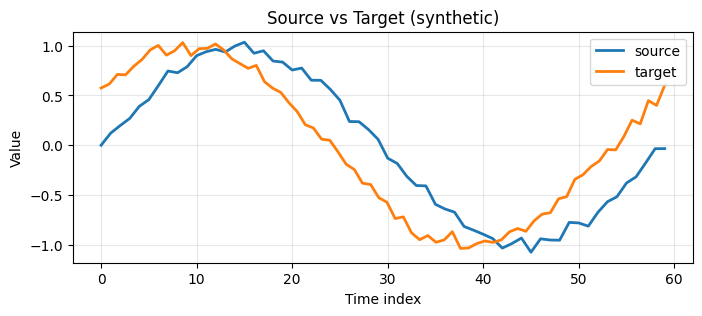

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

length_src = 60
length_tgt = 70

x_t = np.linspace(0, 2 * np.pi, length_src)
y_t = np.linspace(0, 2 * np.pi, length_tgt)

xs = np.sin(x_t) + 0.05 * rng.normal(size=length_src)
xt = np.sin(y_t + 0.6) + 0.05 * rng.normal(size=length_tgt)

xs = xs.reshape(-1, 1)
xt = xt.reshape(-1, 1)

p = np.ones(length_src) / length_src
q = np.ones(length_tgt) / length_tgt

print("xs shape:", xs.shape, "xt shape:", xt.shape)
print("xs mean/std:", xs.mean(), xs.std())
print("xt mean/std:", xt.mean(), xt.std())

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(xs.squeeze(), label="source", linewidth=2)
ax.plot(np.linspace(0, len(xs) - 1, len(xt)), xt.squeeze(), label="target", linewidth=2)
ax.set_title("Source vs Target (synthetic)")
ax.set_xlabel("Time index")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 2. Compute Transport on a Single Series

Compute a transport plan and a simple transported series via barycentric mapping.

n:\Fun\TMW
n:\Fun\TMW\examples
{'cost_function': 'L2', 'mask_type': 1, 'algorithm': 'sinkhorn', 'normalized': True, 'reg': 0.0001, 'max_iterations': 2000, 'thres': 1e-06, 'eps_threshold': 0.2, 'masked': True, 'rescale': True}
TMW distance: 0.008366613515255042
pi shape: (60, 70)
transported_xs shape: (60, 1)


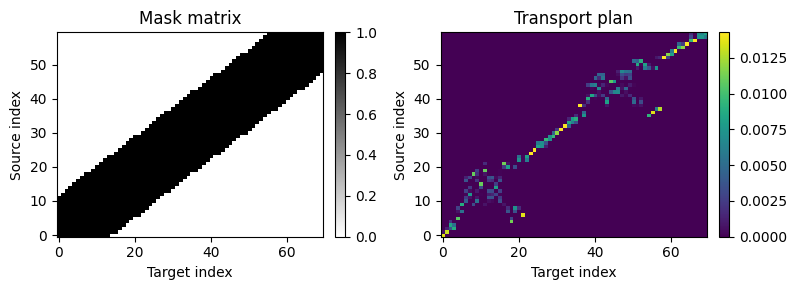

In [2]:
%cd ..
from tmw_package.temporal_masked_OT import TemporalMaskedWasserstein
%cd examples

tmw = TemporalMaskedWasserstein()

config = {
    "cost_function": "L2",
    "mask_type": 1,
    "algorithm": "sinkhorn",
    "normalized": True,
    "reg": 0.0001,
    "max_iterations": 2000,
    "thres": 1e-6,
    "eps_threshold": 0.2,
    "masked": True,
    "rescale": True
}

print(config)

pi = tmw.tmw(p, q, xs, xt, **config)

distance = tmw.tmwd(p, q, xs, xt, **config)
print("TMW distance:", float(distance))

row_sums = pi.sum(axis=1, keepdims=True) + 1e-12
transported_xs = (pi @ xt) / row_sums

print("pi shape:", pi.shape)
print("transported_xs shape:", transported_xs.shape)

mask = tmw.mask_matrix(xs, xt, config["mask_type"], config["eps_threshold"], config["rescale"])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

im_mask = axes[0].imshow(mask, aspect="auto", origin="lower", cmap="gray_r")
axes[0].set_title("Mask matrix")
axes[0].set_xlabel("Target index")
axes[0].set_ylabel("Source index")
fig.colorbar(im_mask, ax=axes[0], fraction=0.046, pad=0.04)

im_pi = axes[1].imshow(pi, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Transport plan")
axes[1].set_xlabel("Target index")
axes[1].set_ylabel("Source index")
fig.colorbar(im_pi, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Batch Transport for Multiple Series

Apply TMW transport across a small batch of phase-shifted series.

In [3]:
def make_pair(phase_shift, noise_scale=0.05):
    x_t = np.linspace(0, 2 * np.pi, length_src)
    y_t = np.linspace(0, 2 * np.pi, length_tgt)
    xs = np.sin(x_t) + noise_scale * rng.normal(size=length_src)
    xt = np.sin(y_t + phase_shift) + noise_scale * rng.normal(size=length_tgt)
    return xs.reshape(-1, 1), xt.reshape(-1, 1)

batch_size = 4
phase_shifts = np.linspace(0.2, 1.0, batch_size)

batch_transported = []
for phase in phase_shifts:
    xs_i, xt_i = make_pair(phase)
    p_i = np.ones(xs_i.shape[0]) / xs_i.shape[0]
    q_i = np.ones(xt_i.shape[0]) / xt_i.shape[0]
    pi_i = tmw.tmw(p_i, q_i, xs_i, xt_i, **config)
    row_sums_i = pi_i.sum(axis=1, keepdims=True) + 1e-12
    transported_i = (pi_i @ xt_i) / row_sums_i
    batch_transported.append({
        "xs": xs_i,
        "xt": xt_i,
        "transported": transported_i,
    })

print("batch size:", len(batch_transported))

batch size: 4


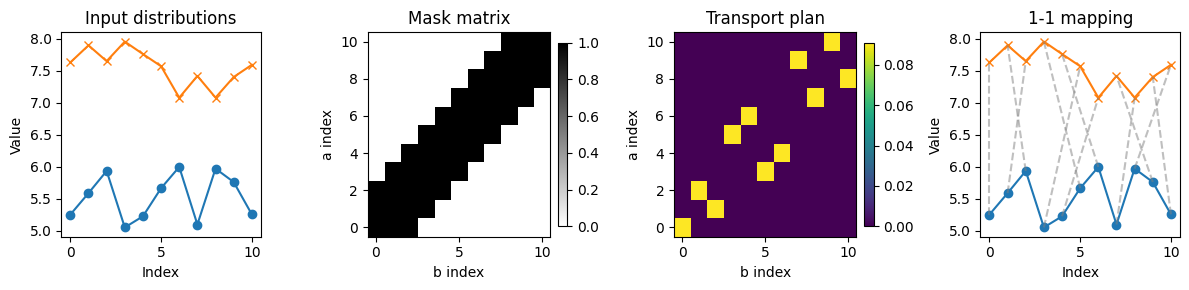

In [20]:
config["algorithm"] = "linear_programming"

a = np.random.rand(11) + 5
b = np.random.rand(11) + 7

t = tmw.tmw(np.ones(len(a)) / len(a), np.ones(len(b)) / len(b), a.reshape(-1, 1), b.reshape(-1, 1), **config)

m = tmw.mask_matrix(a.reshape(-1, 1), b.reshape(-1, 1), config["mask_type"], config["eps_threshold"], config["rescale"])

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Plot a and b in the first plot, t in the second, and the mask in the third. In the fourth plot, plot a and b again, but with a line to show the 1-1 correspondence as indicated by the mask.

axes[0].plot(a, label="a", marker="o")
axes[0].plot(b, label="b", marker="x")
axes[0].set_title("Input distributions")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Value")
im_t = axes[2].imshow(t, aspect="auto", origin="lower", cmap="viridis")
axes[2].set_title("Transport plan")
axes[2].set_xlabel("b index")
axes[2].set_ylabel("a index")
fig.colorbar(im_t, ax=axes[2], fraction=0.046, pad=0.04)
im_m = axes[1].imshow(m, aspect="auto", origin="lower", cmap="gray_r")
axes[1].set_title("Mask matrix")
axes[1].set_xlabel("b index")
axes[1].set_ylabel("a index")
fig.colorbar(im_m, ax=axes[1], fraction=0.046, pad=0.04)

axes[3].plot(a, label="a", marker="o")
axes[3].plot(b, label="b", marker="x")
for i in range(len(a)):
    for j in range(len(b)):
        if t[i, j] > 0.05:  
            axes[3].plot([i, j], [a[i], b[j]], color="gray", linestyle="--", alpha=0.5)
axes[3].set_title("1-1 mapping")
axes[3].set_xlabel("Index")
axes[3].set_ylabel("Value")
plt.tight_layout()
plt.show()
